# Heart Stroke Prediction: Clustering Analysis

### 1. Unsupervised Clustering Techniques

These methods group similar data points without using predefined labels. 

#### **Partitioning (Centroid-based):**

- **K-Means**: The most common technique; it partitions data into \(k\) clusters by minimizing distances to a central "mean".

- **K-Medoids (PAM)**: More robust to outliers than K-Means because it uses actual data points as centroids.

#### **Density-based:**

- **DBSCAN**: Identifies dense regions as clusters and flags scattered points in low-density areas as outliers (noise).

- **OPTICS**: Similar to DBSCAN but better at handling clusters with varying densities.

#### **Hierarchical (Connectivity-based):**

- **Agglomerative**: A "bottom-up" approach where each point starts as its own cluster and merges with the closest neighbor.

- **Divisive**: A "top-down" approach that starts with one large cluster and splits it recursively.

### 2. Unsupervised Outlier Detection

#### **Proximity-based:**

- **Local Outlier Factor (LOF)**: Measures the local density of a point relative to its neighbors. Points with much lower density are flagged as outliers.

- **K-Nearest Neighbors (KNN)**: Scores "outlierness" based on a point's distance to its $(k^{th})$ nearest neighbor.

#### **Model-based / Ensemble**:

- **Isolation Forest**: Randomly partitions features to "isolate" points. Outliers are isolated much faster (shorter path length) than normal points.

- **One-Class SVM**: Learns a boundary of "normality" and flags points falling outside it.

### 3. Dimensionality Reduction (For Visualization)

Essential for high-dimensional data (like heart stroke datasets) to see clusters in 2D or 3D. 

- **PCA (Principal Component Analysis)**: Linear reduction that preserves maximum variance.

- **t-SNE**: Non-linear reduction excellent for visualizing distinct clusters in 2D space

### Library version problem

In [1]:
import matplotlib
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn import set_config
set_config(transform_output="pandas", display="diagram")

print("Seaborn version: ",sns.__version__)
print("Numpy version: ",np.__version__)
print("Matplotlib version: ",matplotlib.__version__)

# Seaborn version:  0.12.2 # this gives bar plot color, but heatmap have error
# Numpy version:  1.24.4
# Seaborn version:  0.13.0 # this gives bar plot no color , but heatmap no error solved

# matplot version : 3.7.3
# 3 solves all the problems

Seaborn version:  0.12.2
Numpy version:  2.3.5
Matplotlib version:  3.10.8


## Imports

In [2]:


# data manupulation
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
%pwd

'/Users/rahulshelke/Documents/Data-Science/Data-Science-Projects/heart-stroke-prediction'

In [4]:
cd notebooks/

/Users/rahulshelke/Documents/Data-Science/Data-Science-Projects/heart-stroke-prediction/notebooks


In [5]:
DATA_PATH = os.path.join("data", "heart_stroke_data.csv")
ARTIFACT_PATH = "artifacts"

## Reading Data

**Import the CSV Data as Pandas DataFrame**

In [6]:
df = pd.read_csv(DATA_PATH)

### **Show Top 5 Records**

In [7]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,male,67.0,0,1,yes,private,urban,228.69,36.6,formerly_smoked,1
1,51676,female,61.0,0,0,yes,self_employed,rural,202.21,NaN,never_smoked,1
2,31112,male,80.0,0,1,yes,private,rural,105.92,32.5,never_smoked,1
3,60182,female,49.0,0,0,yes,private,urban,171.23,34.4,smokes,1
4,1665,female,79.0,1,0,yes,self_employed,rural,174.12,24.0,never_smoked,1


In [8]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,female,80.0,1,0,yes,private,urban,83.75,NaN,never_smoked,0
5106,44873,female,81.0,0,0,yes,self_employed,urban,125.20,40.0,never_smoked,0
5107,19723,female,35.0,0,0,yes,self_employed,rural,82.99,30.6,never_smoked,0
5108,37544,male,51.0,0,0,yes,private,rural,166.29,25.6,formerly_smoked,0
5109,44679,female,44.0,0,0,yes,govt_job,urban,85.28,26.2,NaN,0


### **Dropping NaN**

In [11]:
df.isna().sum()/df.shape[0]*100

id                    0.000000
gender                0.000000
age                   0.000000
hypertension          0.000000
heart_disease         0.000000
ever_married          0.000000
work_type             0.000000
residence_type        0.000000
avg_glucose_level     0.000000
bmi                   3.933464
smoking_status       30.215264
stroke                0.000000
dtype: float64

In [83]:
df_complete_cols = df.dropna(subset=['bmi', 'smoking_status'], axis='index', ignore_index=True).drop(columns=['id', 'stroke'])
df_reduced_cols = df.drop(columns=['id', 'bmi', 'smoking_status', 'stroke'],)

In [84]:
df_complete_cols.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status
0,male,67.0,0,1,yes,private,urban,228.69,36.6,formerly_smoked
1,male,80.0,0,1,yes,private,rural,105.92,32.5,never_smoked
2,female,49.0,0,0,yes,private,urban,171.23,34.4,smokes
3,female,79.0,1,0,yes,self_employed,rural,174.12,24.0,never_smoked
4,male,81.0,0,0,yes,private,urban,186.21,29.0,formerly_smoked


In [85]:
df_complete_cols.isna().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
dtype: int64

In [86]:
df_reduced_cols.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level
0,male,67.0,0,1,yes,private,urban,228.69
1,female,61.0,0,0,yes,self_employed,rural,202.21
2,male,80.0,0,1,yes,private,rural,105.92
3,female,49.0,0,0,yes,private,urban,171.23
4,female,79.0,1,0,yes,self_employed,rural,174.12


In [87]:
df_reduced_cols.isna().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
residence_type       0
avg_glucose_level    0
dtype: int64

### **Feature Information**

- Here we used the heart stroke dataset that is available in the kaggle website for our analysis. This datasets consists of total 12 attributes. The complete description of the attributes used in the proposed work is given below.

- **id**: This attribute means person's id. it's numerical data.

- **Age**: This attribute means a persons age. it's numerical data.

- **Gender**: This attribute means a person's gender, it's categorical data.

- **Hypertension**: This attribute means that this person is hypertensive or not. it's numerical data.

- **work type**: This attribute represents the person work scenario. it's categorical data.

- **residence type**: This attribute represnts the person work scenario. it's categorical data.

- **heart disease**: This attribute means wheather this person has a heart disease person or not. it's numerical data.

- **avg_glucose_level**: This attribute means what was the level of a person's glucose condition. it's numercial data.

- **Bmi**: This attribute represents a person's married status. it's categorical data.

- **ever_married**: This attribute represents a person's married status. it's categorical data.

- **smoking_status**: This attribute means a person's smoking condition. it's categorical data.

- **Stroke**: This attribute means a person previously had a choise or not.

### **Feature Engineering**

In [92]:

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn import set_config
set_config(transform_output="pandas", display="diagram")

In [93]:
df_complete_cols.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status'],
      dtype='object')

#### **Feature Engineering : Complete cols pipeline**

In [96]:
complete_cols_pipeline = Pipeline(
    steps=[
        ('preprocess', 
            ColumnTransformer(
                transformers=[
                    ('categorical_pipeline', OneHotEncoder(sparse_output=False), ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status'] ),
                ],
                remainder='passthrough',
                verbose_feature_names_out=False
            )
        ),
        ('scaler', StandardScaler())
    ]
)

In [97]:
complete_cols_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [99]:
X_complete_processed = complete_cols_pipeline.fit_transform(df_complete_cols)

In [105]:
df_complete_cols.shape

(3426, 10)

#### **Feature Engineering : Reduced cols pipeline**

In [100]:
reduced_cols_pipeline = Pipeline(
    steps=[
        ('preprocess', 
            ColumnTransformer(
                transformers=[
                    ('categorical_pipeline', OneHotEncoder(sparse_output=False), ['gender', 'ever_married', 'work_type', 'residence_type'] ),
                ],
                remainder='passthrough',
                verbose_feature_names_out=False
            )
        ),
        ('scaler', StandardScaler())
    ]
)

In [101]:
X_reduced_processed = reduced_cols_pipeline.fit_transform(df_reduced_cols)

In [106]:
X_reduced_processed.shape

(5110, 16)

## **Dimensionality Reduction (For Visualization):**

In [143]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt

### **PCA (Principal Component Analysis):**

In [140]:
pca = PCA(n_components=2)
X_complete_pca = pca.fit_transform(X_complete_processed)

### **t-SNE**

In [141]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_complete_tsne = tsne.fit_transform(X_complete_processed)

### **UMAP**

In [142]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_complete_umap = reducer.fit_transform(X_complete_processed)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


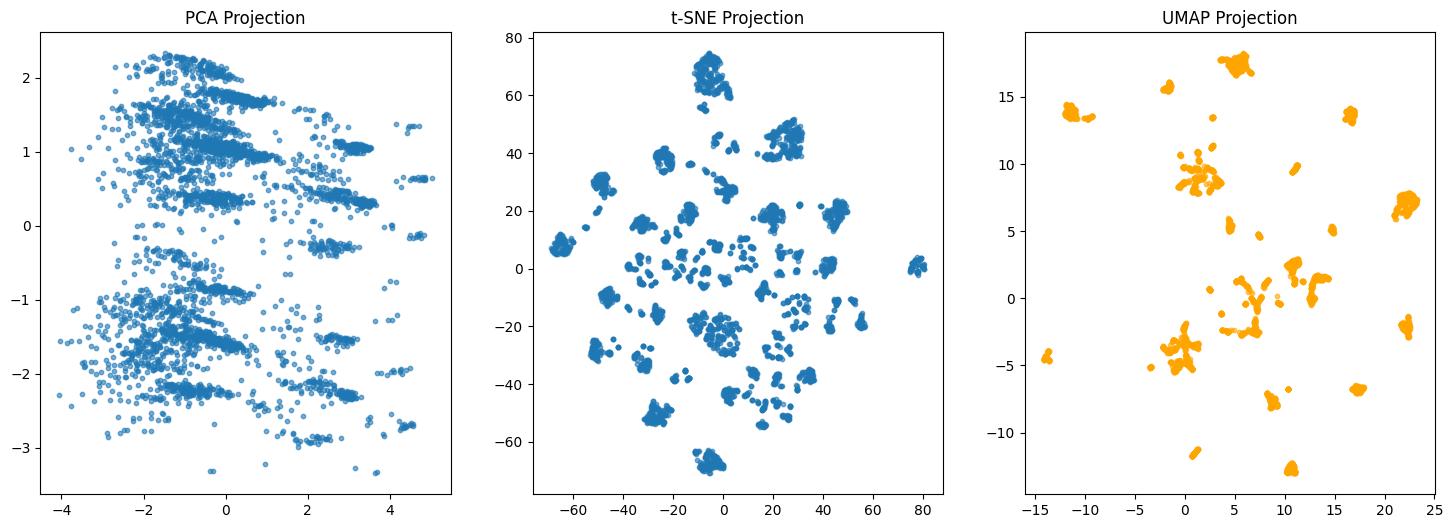

In [153]:
# --- Visualization ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Plot pca
ax1.scatter(X_complete_pca.iloc[:, 0], X_complete_pca.iloc[:, 1], alpha=0.6, s=10)
ax1.set_title('PCA Projection')

# Plot t-SNE
ax2.scatter(X_complete_tsne.iloc[:, 0], X_complete_tsne.iloc[:, 1], alpha=0.6, s=10)
ax2.set_title('t-SNE Projection')

# Plot UMAP
ax3.scatter(X_complete_umap[:, 0], X_complete_umap[:, 1], alpha=0.6, s=10, color='orange')
ax3.set_title('UMAP Projection')

plt.show()

# 1. Unsupervised Clustering Techniques

## **Partitioning (Centroid-based):**

### **1. K-Means**

In [134]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

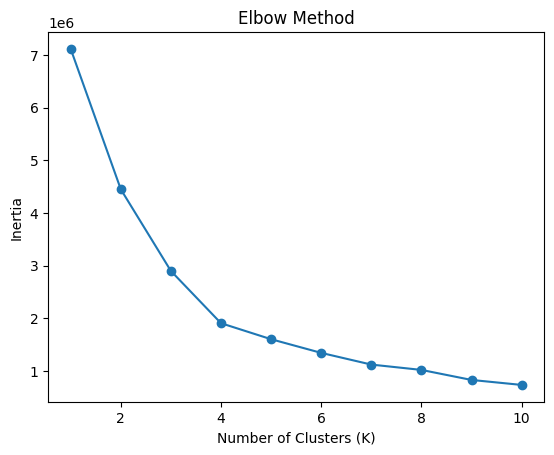

In [168]:
# Calculate inertia for different values of K
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_complete_tsne)
    inertia.append(kmeans.inertia_)

# Plot inertia vs K
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

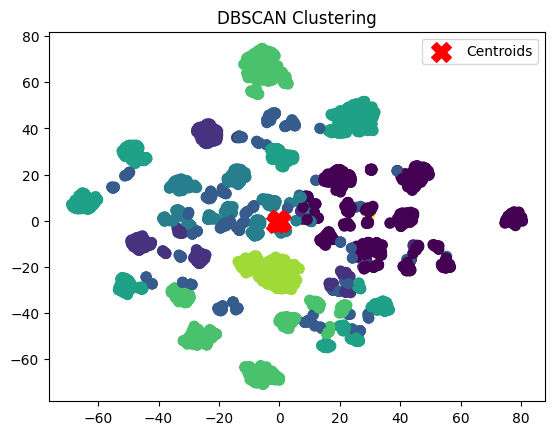

In [171]:
# Apply KMeans with K=4
kmeans = KMeans(n_clusters=8, random_state=42)
kmeans.fit(X_complete_processed)

# Get the predicted cluster centers and labels
centroids = kmeans.cluster_centers_
labels = kmeans.labels_

pca = PCA(n_components=2)
X = pca.fit_transform(X_complete_tsne)

# Visualize the clusters
plt.scatter(X_complete_tsne.iloc[:, 0], X_complete_tsne.iloc[:, 1], c=labels, cmap='viridis', s=50)
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', marker='X', label="Centroids")
plt.title("DBSCAN Clustering")
plt.legend()
plt.show()


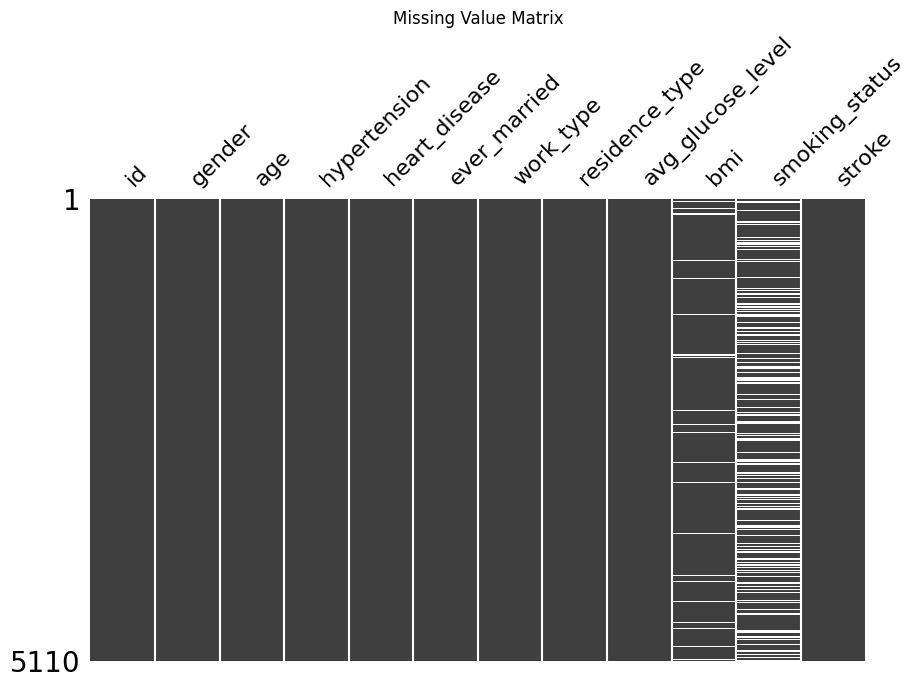

In [17]:
visualize.plot_missing_matrix()

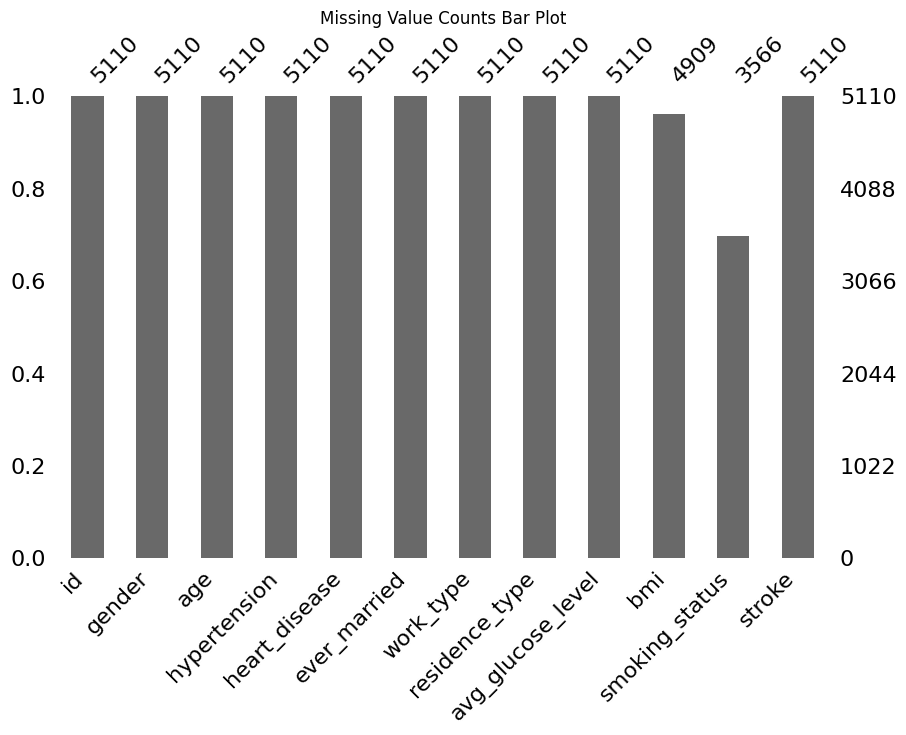

In [18]:
visualize.plot_missing_barplot()

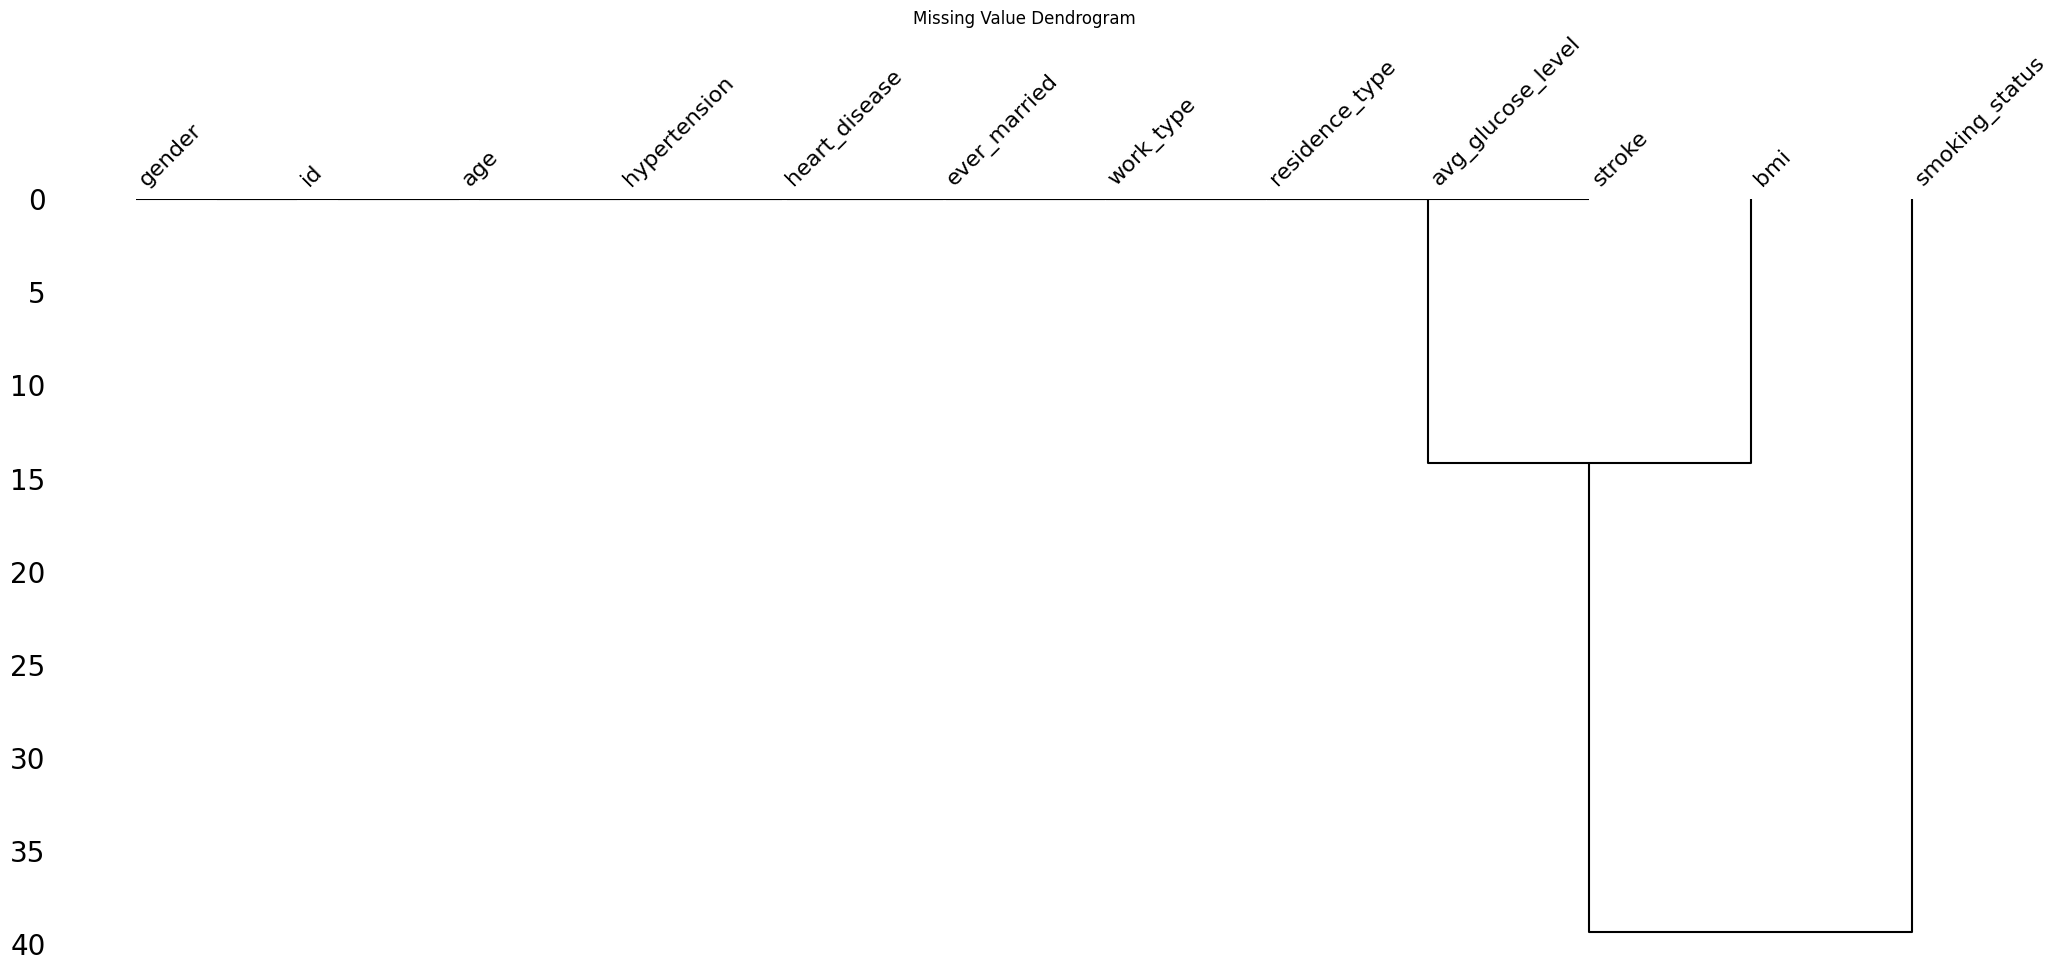

In [19]:
visualize.plot_missing_dendrogram()

- The dendrogram allows you to more fully correlate variable completion, revealing trends deeper than the pairwise ones visible in the correlation heatmap.

- The dendrogram uses a hierarchical clustering algorithm (courtesy of scipy) to bin variables against one another by their nullity correlation (measured in terms of binary distance).

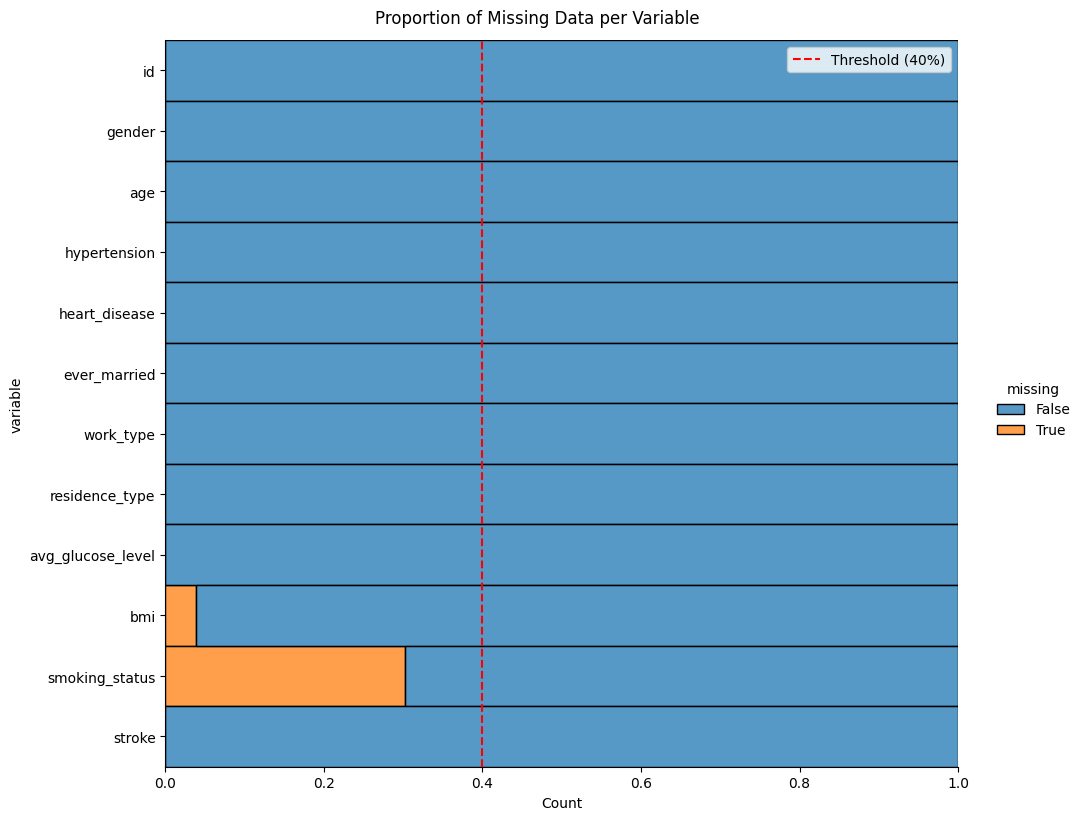

In [20]:
visualize.plot_missing_frequency_displot()

- Around 4% of the BMI data is missing in the dataset
- Smoking habit information is missing for 30% of the population

# Missing Value Analysis



Let's try to identify why ?

- MNAR: missing due to value it self
    - BMI is missing because the patient felt their weight was too high or too low to disclose.
    - Smoking status is missing because heavy smokers or individuals who perceive their habit as a health risk—especially those already managing **hypertension—intentionally** withheld their information to avoid medical or social judgment, meaning the missingness is directly caused by the **actual value** (smoking) being hidden.

- MAR: missing due to other variable
    - BMI is missing for elderly patients because the clinic's standard procedure for patients over 80 doesn't always require a weigh-in.
    - Individuals may conceal their **smoking status** due to the social stigma surrounding **minors** and **females** smoking, or because their **work type** and **residence** create professional and community pressures, especially when managing health conditions like **hypertension**.

- MCAR: really missing
    - BMI is missing because the weighing scale battery died for a few random patients.
    - Smoking status information is missing for some individuals because a **technical glitch** in the digital survey randomly failed to save certain responses, or a **batch of paper questionnaires** containing those records was accidentally lost in transit, independent of the participant's age, gender, or health conditions

## **Missing Not At Random:**

Consult with doctors or researchers who collect this kind of data. We have to ask them directly: "Are patients with high or low BMIs known to avoid reporting their weight?" They will likely confirm this bias exists (meaning it's likely MNAR).

**Limitation:** No access to data lineage or SME for conclusion

## **Missing Completely At Random:**

In [21]:
related_cols = ['age', 'avg_glucose_level', 'gender', 'hypertension', 
                'heart_disease', 'ever_married', 'work_type', 'residence_type']

## BMI

### **visual evidence**

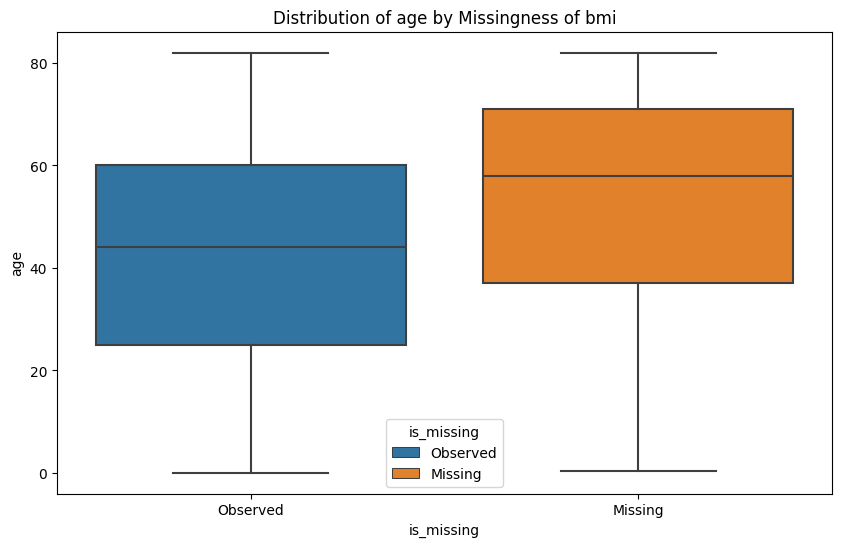

In [22]:
visualize.plot_comparison_by_missingness('bmi', 'age')

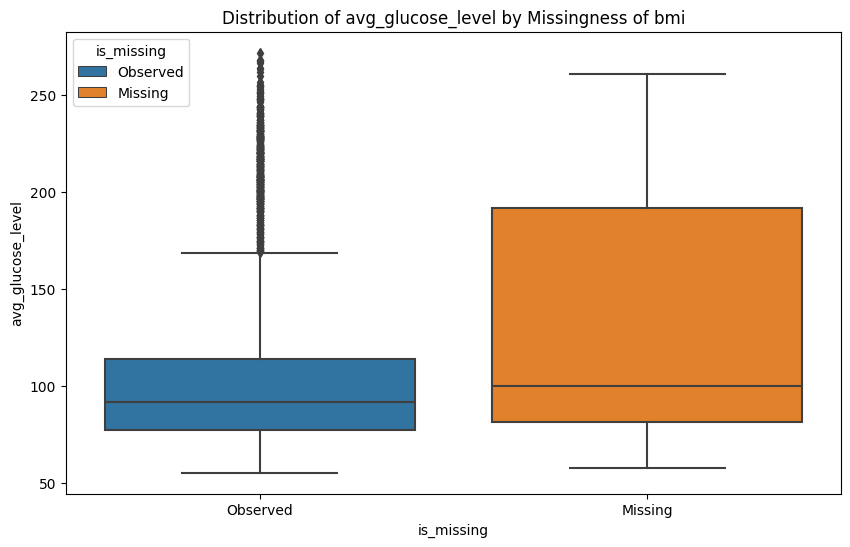

In [23]:
visualize.plot_comparison_by_missingness('bmi', 'avg_glucose_level')

In [40]:
# visualize.plot_comparison_by_missingness('bmi', 'gender', 'stacked_percent_bar')

- gender don't show significant difference

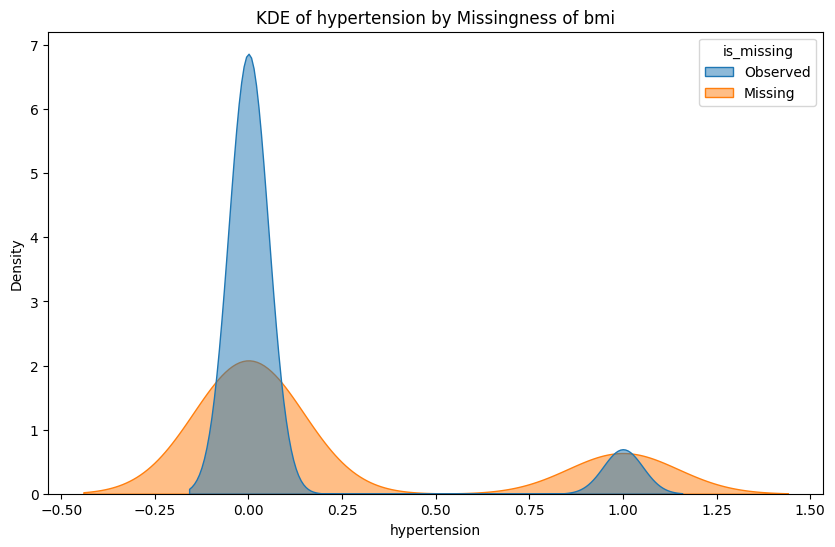

In [25]:
visualize.plot_comparison_by_missingness('bmi', 'hypertension', 'kde')

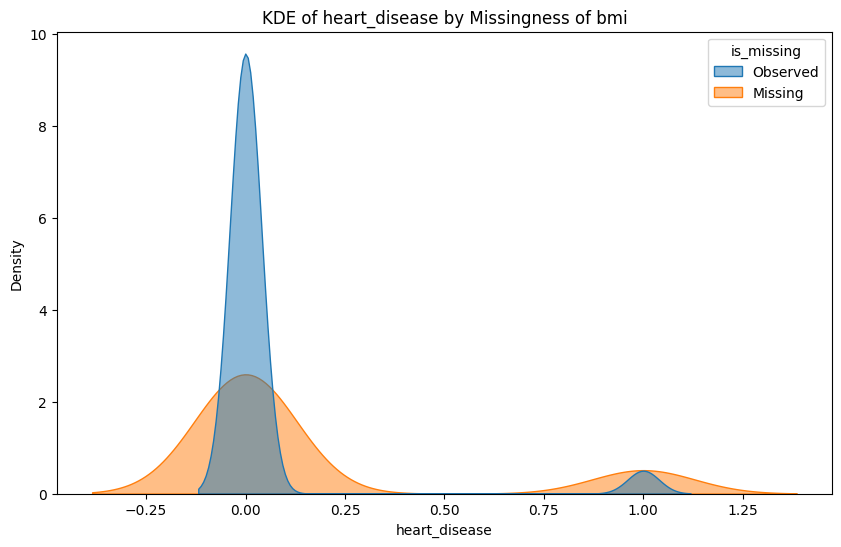

In [26]:
visualize.plot_comparison_by_missingness('bmi', 'heart_disease', 'kde')

In [41]:
# visualize.plot_comparison_by_missingness('bmi', 'ever_married', 'stacked_percent_bar')

- marrige don't show significant difference

<Figure size 1000x600 with 0 Axes>

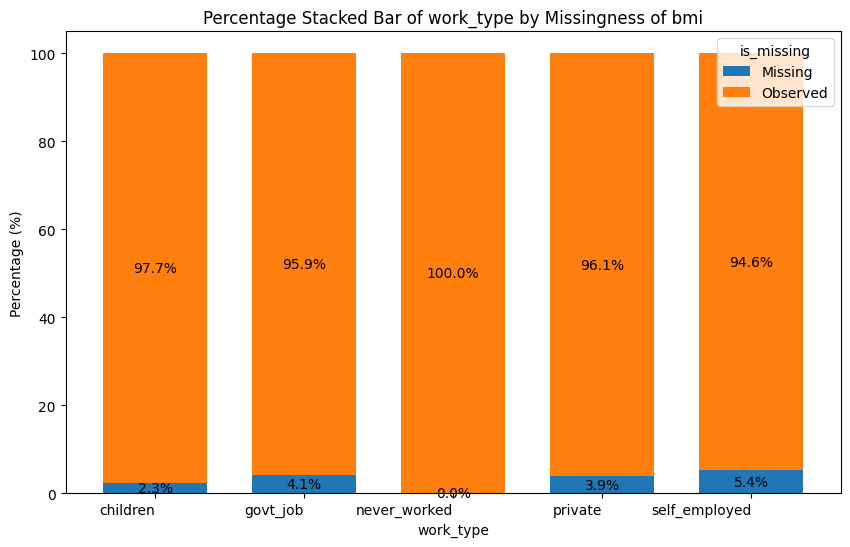

In [28]:
visualize.plot_comparison_by_missingness('bmi', 'work_type', 'stacked_percent_bar')

In [42]:
# visualize.plot_comparison_by_missingness('bmi', 'residence_type', 'stacked_percent_bar')

- residence don't show significant difference

### **statistical evidence**

In [30]:
related_cols = ['age', 'avg_glucose_level', 'gender', 'hypertension', 
                'heart_disease', 'ever_married', 'work_type', 'residence_type']

**BMI**

In [31]:
describe.classify_missingness_mcar_mar("bmi", related_cols)


--- Testing MCAR/MAR for 'bmi' against 8 related columns ---


,Related Column,Test Used,P-value,Conclusion
0,age,Independent T-test,0.0000,MAR (Dependent/Related)
1,avg_glucose_level,Independent T-test,0.0000,MAR (Dependent/Related)
3,hypertension,Independent T-test,0.0000,MAR (Dependent/Related)
4,heart_disease,Independent T-test,0.0000,MAR (Dependent/Related)
2,gender,Chi-squared Test,0.0097,MAR (Dependent/Related)
5,ever_married,Chi-squared Test,0.0118,MAR (Dependent/Related)
6,work_type,Chi-squared Test,0.0382,MAR (Dependent/Related)
7,residence_type,Chi-squared Test,0.6258,MCAR (Independent/Random)


## **Smoking Status**

### **visual evidence**

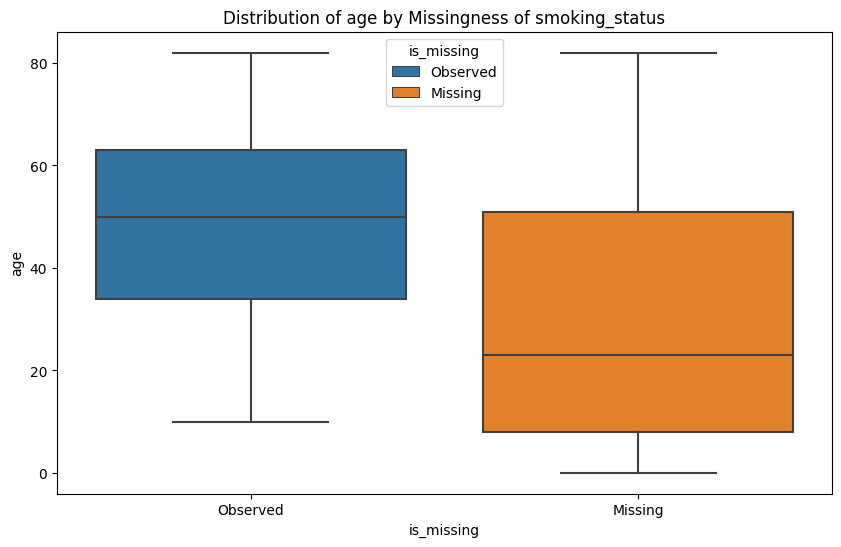

In [32]:
visualize.plot_comparison_by_missingness('smoking_status', 'age')

- diagram says, data is missing about smoking status for minors and adults.

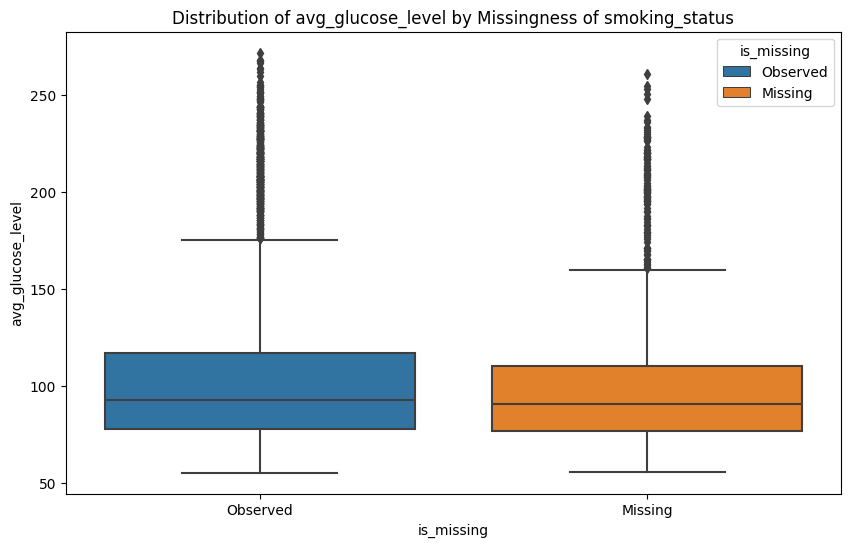

In [33]:
visualize.plot_comparison_by_missingness('smoking_status', 'avg_glucose_level')

In [43]:
# visualize.plot_comparison_by_missingness('smoking_status', 'gender', 'stacked_percent_bar')

- gender don't show significant difference

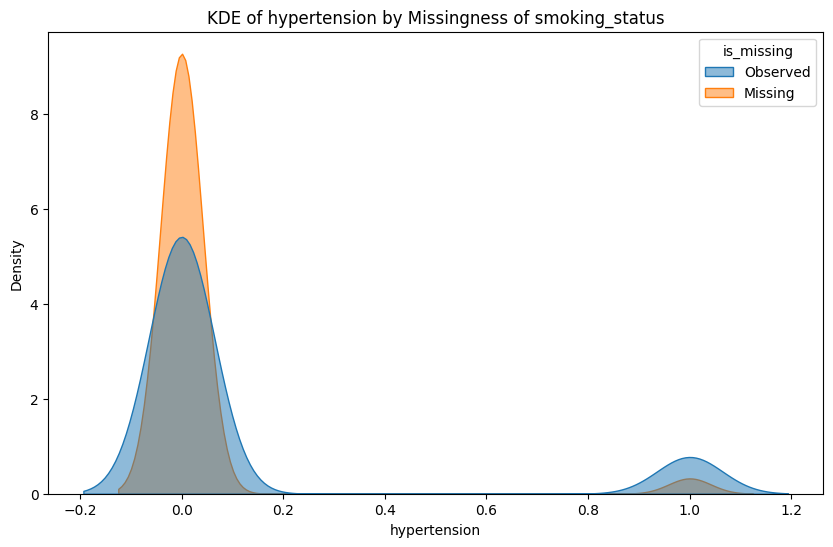

In [35]:
visualize.plot_comparison_by_missingness('smoking_status', 'hypertension', 'kde')

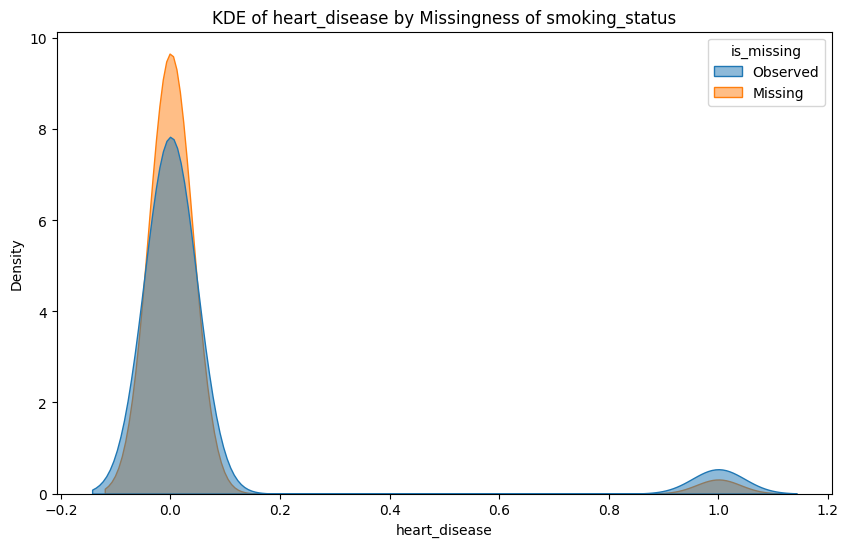

In [36]:
visualize.plot_comparison_by_missingness('smoking_status', 'heart_disease', 'kde')

<Figure size 1000x600 with 0 Axes>

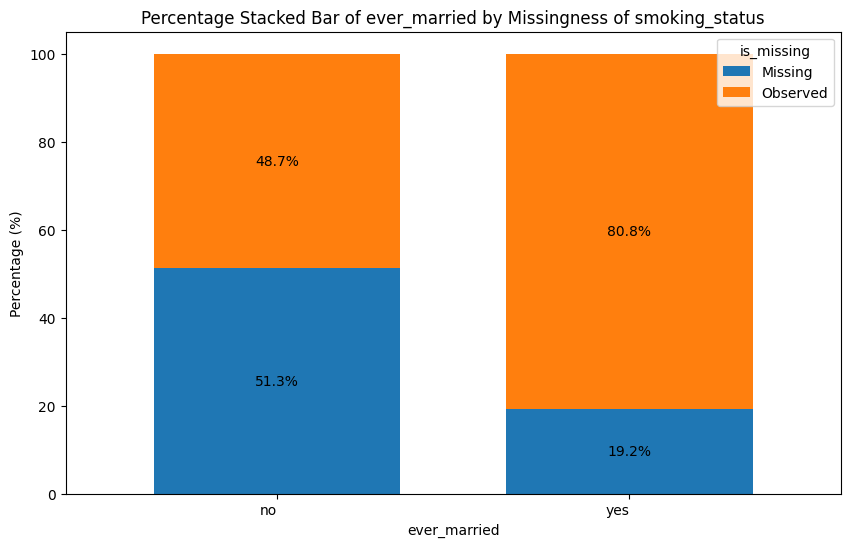

In [37]:
visualize.plot_comparison_by_missingness('smoking_status', 'ever_married', 'stacked_percent_bar')

- **unmarried patients** are not exposing their smoking status

<Figure size 1000x600 with 0 Axes>

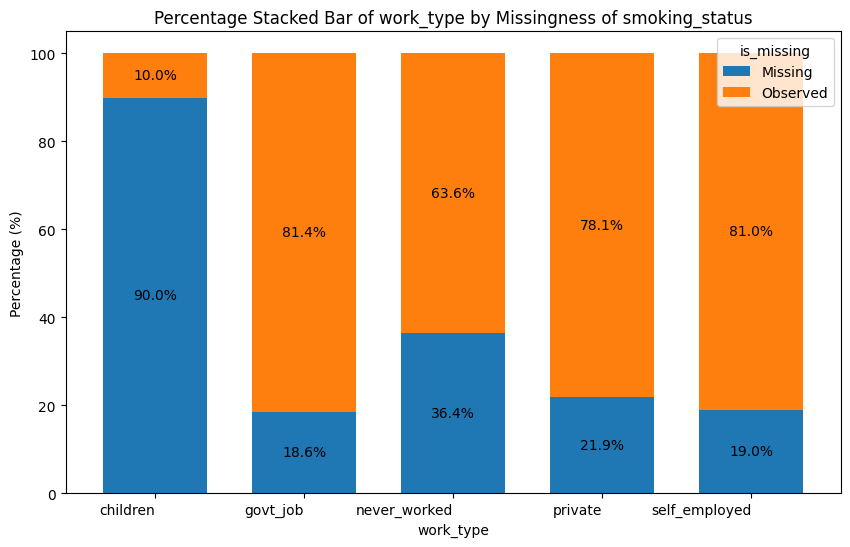

In [38]:
visualize.plot_comparison_by_missingness('smoking_status', 'work_type', 'stacked_percent_bar')

- **90% of childredns** hiding their smoking status
- **36%** of patients who never worked also hiding smoking status 

In [44]:
# visualize.plot_comparison_by_missingness('smoking_status', 'residence_type', 'stacked_percent_bar')

- no difference based on **residence** in which patients are living

### **Smoking Status**

In [45]:
describe.classify_missingness_mcar_mar("smoking_status", related_cols)


--- Testing MCAR/MAR for 'smoking_status' against 8 related columns ---


,Related Column,Test Used,P-value,Conclusion
0,age,Independent T-test,0.0000,MAR (Dependent/Related)
1,avg_glucose_level,Independent T-test,0.0000,MAR (Dependent/Related)
3,hypertension,Independent T-test,0.0000,MAR (Dependent/Related)
4,heart_disease,Independent T-test,0.0000,MAR (Dependent/Related)
5,ever_married,Chi-squared Test,0.0000,MAR (Dependent/Related)
6,work_type,Chi-squared Test,0.0000,MAR (Dependent/Related)
2,gender,Chi-squared Test,0.0001,MAR (Dependent/Related)
7,residence_type,Chi-squared Test,0.9084,MCAR (Independent/Random)


## Little's MCAR

In [ ]:
# !pip install -q pyampute

In [ ]:
# describe.final_missingness_conclusion("bmi", related_cols)

In [ ]:
# describe.final_missingness_conclusion("smoking_status", related_cols)

In [ ]:
# describe.run_littles_mcar_test(["smoking_status"])

In [ ]:
# describe.run_littles_mcar_test(["bmi"])

## Inference:

- except `residence_type`, rest data suggests that missing data show significant difference in missingness

- data suggests `bmi` and `smoking_status` are likely to be **MAR**, means there are other things affecting the missingness

## **Imputing Missing At Random:**

In [167]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, RobustScaler, MinMaxScaler

In [168]:
df = pd.read_csv(DATA_PATH)

In [169]:
df['smoking_status'].unique()

array(['formerly_smoked', 'never_smoked', 'smokes', nan], dtype=object)

In [198]:
custom_categories = ['formerly_smoked', 'never_smoked', 'smokes']

impute_categorical = Pipeline(
    steps=[
        ('ordinal_encoder', OrdinalEncoder(
                                categories=custom_categories,
                                handle_unknown='use_encoded_value',
                                unknown_value=np.nan,
                                )
            ),
        ('knn_imputer', KNNImputer(n_neighbors=1))
    ]
)

impute_numerical = Pipeline(
    steps=[
        ('scaler', RobustScaler()),
        ('imputer', KNNImputer(n_neighbors=1))
    ]
)

In [199]:
imputer_preprocessor = ColumnTransformer(
    transformers=[
        ('num', impute_numerical, ['bmi']),
        ('cat', SimpleImputer(strategy='most_frequent'), ['smoking_status']),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

In [200]:
imputer_preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [201]:
df_corrected = imputer_preprocessor.fit_transform(df)

In [202]:
df_corrected.head()

,bmi,smoking_status,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,stroke
0,0.885417,formerly_smoked,9046,male,67.0,0,1,yes,private,urban,228.69,1
1,0.082629,never_smoked,51676,female,61.0,0,0,yes,self_employed,rural,202.21,1
2,0.458333,never_smoked,31112,male,80.0,0,1,yes,private,rural,105.92,1
3,0.656250,smokes,60182,female,49.0,0,0,yes,private,urban,171.23,1
4,-0.427083,never_smoked,1665,female,79.0,1,0,yes,self_employed,rural,174.12,1


In [203]:
df_corrected.tail()

,bmi,smoking_status,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,stroke
5105,0.082629,never_smoked,18234,female,80.0,1,0,yes,private,urban,83.75,0
5106,1.239583,never_smoked,44873,female,81.0,0,0,yes,self_employed,urban,125.20,0
5107,0.260417,never_smoked,19723,female,35.0,0,0,yes,self_employed,rural,82.99,0
5108,-0.260417,formerly_smoked,37544,male,51.0,0,0,yes,private,rural,166.29,0
5109,-0.197917,never_smoked,44679,female,44.0,0,0,yes,govt_job,urban,85.28,0


In [204]:
imputer_preprocessor.get_feature_names_out(input_features=None)

array(['bmi', 'smoking_status', 'id', 'gender', 'age', 'hypertension',
       'heart_disease', 'ever_married', 'work_type', 'residence_type',
       'avg_glucose_level', 'stroke'], dtype=object)

# **Univariate Analysis**

In [205]:
# Initialize Analyzers
num_uni = NumericalUnivariate(df_corrected)

## Numerical Variables

In [206]:
NUM_FEATURES

['age', 'avg_glucose_level', 'bmi']

**Age**

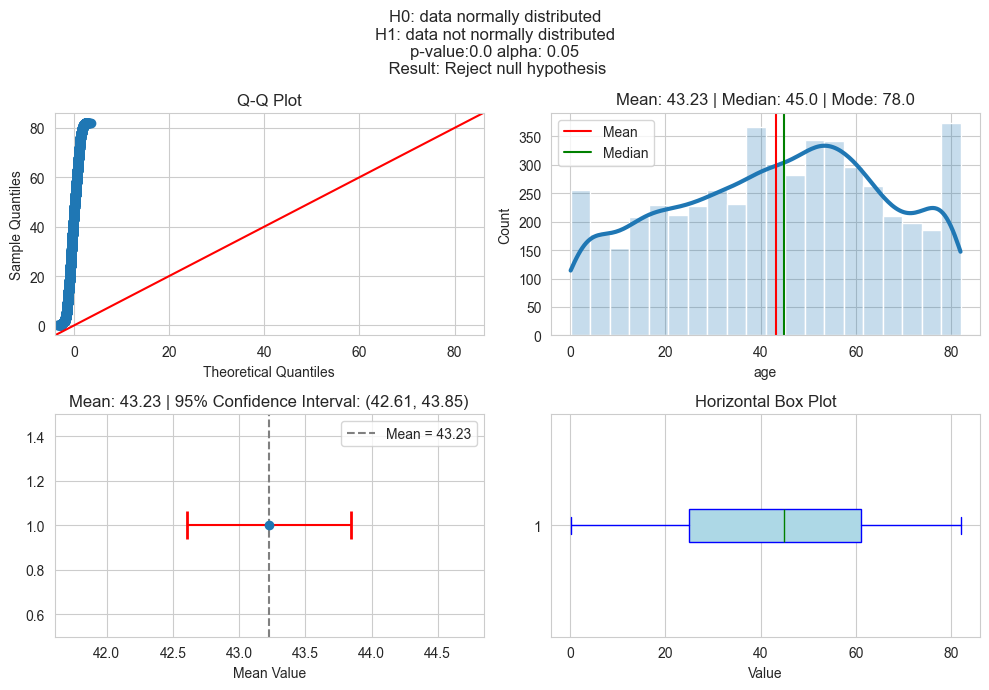

In [207]:
num_uni.plot_numerical_summary("age")

**Avg Glucose Level** 

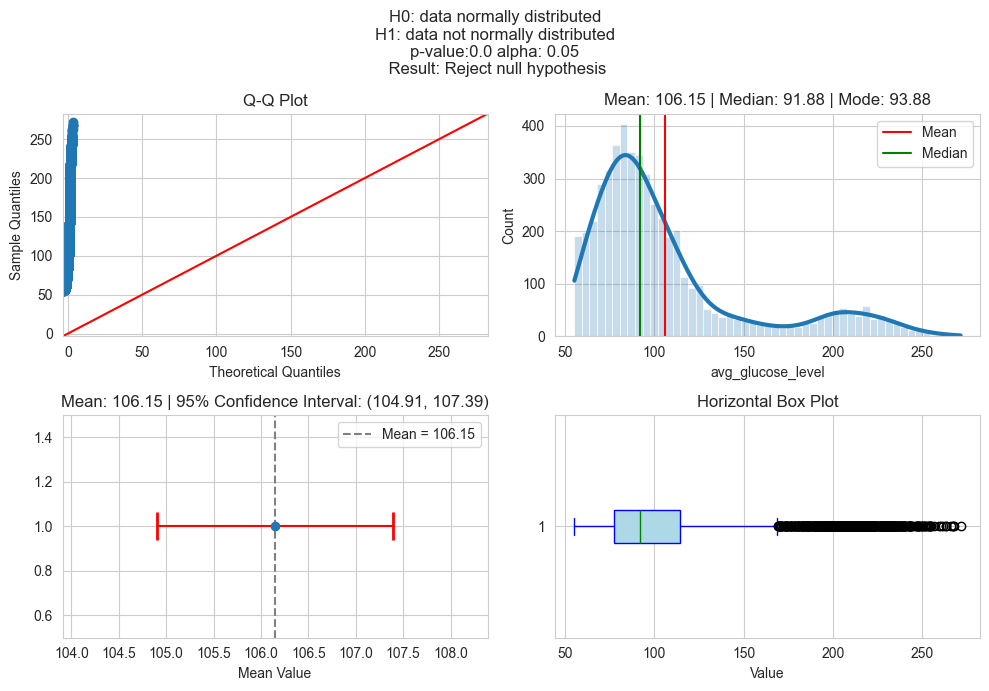

In [208]:
num_uni.plot_numerical_summary("avg_glucose_level")

**BMI**

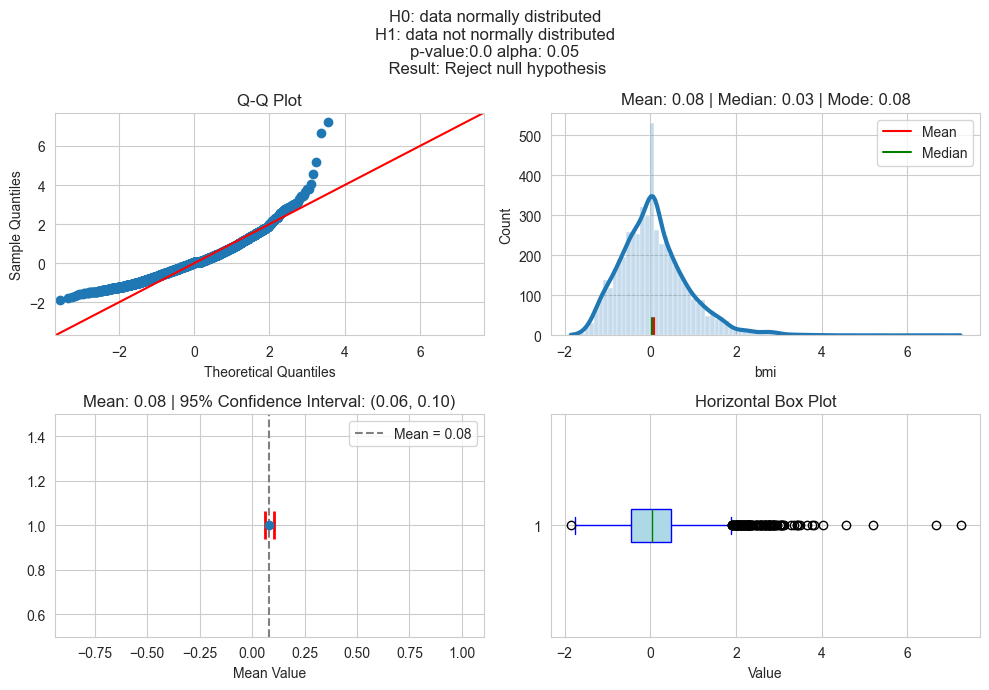

In [209]:
num_uni.plot_numerical_summary("bmi")

### **Conclusion:**

- `age`, `avg_glucose_level` and `bmi` are not normally distributed.
- `avg_glucose_level` and `bmi` are right skewed with lots of outliers.
- `age` is left skewed.

**Variables** | **Distribution** | **Skewness** | **Outliers** 
---|---|---|---
age | Not Normal | Left | No 
avg_glucose_level | Not Normal | Right | Yes 
bmi | Not Normal | Right | Yes 

**Suggestion:**

- Non-parametric test's are preferable for bivariate analysis.
- Try: `log1p`, `sqrt`, `box-cox`, `yeo–johnson`are possible transformation.

## Categorical Variables

- stroke
- gender
- hypertension
- heart_disease
- ever_married
- work_type
- Residence_type
- smoking_status

In [ ]:
CAT_FEATURES

In [ ]:
cat_uni = CategoricalUnivariate(df)

**stroke**

In [ ]:
cat_uni.bootstrap_expected_distribution(df, 'stroke')

In [ ]:
cat_uni.plot_categorical_summary(df, "stroke")

- nearly 5% of total population is having heart attacks

**gender**

In [ ]:
cat_uni.bootstrap_expected_distribution(df, 'gender')

In [ ]:
cat_uni.plot_categorical_summary(df, "gender")

- there are male and females with 60:40 distribution respectively
- `other` has only one record, that can be dropped

**hypertension**

In [ ]:
cat_uni.bootstrap_expected_distribution(df, 'hypertension', 10000)

In [ ]:
cat_uni.plot_categorical_summary(df, "hypertension")

- 10% of population suffering from hypertnesion

**heart_disease**

In [ ]:
cat_uni.bootstrap_expected_distribution(df, 'heart_disease', 10000)

In [ ]:
cat_uni.plot_categorical_summary(df, "heart_disease")

- 5-6% of population suffering heart disease

**ever_married**

In [ ]:
cat_uni.bootstrap_expected_distribution(df, 'ever_married', 10000)

In [ ]:
cat_uni.plot_categorical_summary(df, "ever_married")

- 65% of the population is commited

**work_type**

In [ ]:
cat_uni.bootstrap_expected_distribution(df, 'work_type', 10000)

In [ ]:
cat_uni.plot_categorical_summary(df, "work_type")

- ~57% of population work for `private` organizations
- ~16% are `self-employeed`
- ~14% are `children`
- ~12% work for `government`
- < 1% of population `never worked`

**Suggestion:**

- can combine `children` and `never_worked` categories (but check their ages).

**Residence_type**

In [ ]:
cat_uni.bootstrap_expected_distribution(df, 'residence_type', 10000)

In [ ]:
cat_uni.plot_categorical_summary(df, "residence_type")

- population is equally distributed between `Rural` and `Urban` region

**smoking_status**

In [ ]:
cat_uni.bootstrap_expected_distribution(df, 'smoking_status', 10000)

In [ ]:
cat_uni.plot_categorical_summary(df, "smoking_status")

- ~83% population `never smoked`
- 18% of population `used_to_smoke`, but has quit.

### **Conclusion:**

**Variables** | **Distribution** | **Missing**
---|---|---
stroke | Imbalanced | No
gender | Imbalanced | No
hypertension | Imbalanced | No
heart_disease | Imbalanced | No 
ever_married | Imbalanced | No 
work_type | Imbalanced | No 
residence_type | Balanced | No 
smoking_status | Imbalanced | No

# Bivariate Analysis

## 1. Categorical - Numerical

- stroke Vs age
- stroke Vs avg_glucose_level
- stroke Vs bmi

In [ ]:
cat_num_bi = CategoricalNumericalBivariate(df)

### 1. Stroke Vs Age

In [ ]:
cat_num_bi.create_agg_table("stroke", "age")

In [ ]:
cat_num_bi.plot_violinplot_sns("stroke", "age")

In [ ]:
cat_num_bi.plot_boxplot_plotly("stroke", "age")

In [ ]:
cat_num_bi.plot_density_by_category("stroke", "age")

In [ ]:
cat_num_bi.test_group_means("stroke", "age")

In [ ]:
cat_num_bi.suggest_imputation_strategy("stroke", "age")

### 2. Stroke Vs Avg Glucose Level

In [ ]:
cat_num_bi.create_agg_table("stroke", "avg_glucose_level")

In [ ]:
cat_num_bi.plot_boxplot_plotly("stroke", "avg_glucose_level")

In [ ]:
cat_num_bi.plot_density_by_category("stroke", "avg_glucose_level")

In [ ]:
cat_num_bi.test_group_means("stroke", "avg_glucose_level")

In [ ]:
cat_num_bi.suggest_imputation_strategy("stroke", "avg_glucose_level")

- with outliers it's hard to conlude, that glucose levels are really contirbuting in getting stroke

### 3. Stroke Vs BMI

In [ ]:
cat_num_bi.create_agg_table("stroke", "bmi")

In [ ]:
cat_num_bi.plot_boxplot_plotly("stroke", "bmi")

In [ ]:
cat_num_bi.plot_density_by_category("stroke", "bmi")

In [ ]:
cat_num_bi.test_group_means("stroke", "bmi")

In [ ]:
cat_num_bi.suggest_imputation_strategy("stroke", "bmi")

### **Final Conclusion:**

**Feature** | **Relation with Stroke** 
--- | ---
 Age | Yes
 Avg Glucose Level | Yes (outliers present)
 BMI | Yes (outliers present)

## 2. Categorical - Categorical

- Stroke Vs. Gender - categorical
- Stroke Vs. Hypertension - categorical
- Stroke Vs. Heart Disease - numerical
- Stroke Vs. Ever Married - numerical
- Stroke Vs. Work Type - categorical
- Stroke Vs. Residence Type - categorical
- Stroke Vs. Smoking Status - categorical


In [ ]:
cat_cat_bva = CategoricalCategoricalBivariate(df)

### 1. Stroke Vs Gender

In [ ]:
cat_cat_bva.create_contingency_table("stroke", "gender")

In [ ]:
cat_cat_bva.plot_stacked_barplot_sns("stroke", "gender")

In [ ]:
cat_cat_bva.plot_heatmap_contingency("stroke", "gender")

In [ ]:
cat_cat_bva.test_chi_squared_independence("stroke", "gender")

In [ ]:
cat_cat_bva.calculate_cramers_v("stroke", "gender")

- gender doesn't have any significant impact on stroke

### 2. Stroke Vs. Hypertension

In [ ]:
cat_cat_bva.create_contingency_table("stroke", "hypertension")

In [ ]:
cat_cat_bva.plot_heatmap_contingency("stroke", "hypertension")

In [ ]:
cat_cat_bva.plot_stacked_barplot_sns("stroke", "hypertension")

In [ ]:
cat_cat_bva.test_chi_squared_independence("stroke", "hypertension")

In [ ]:
cat_cat_bva.calculate_cramers_v("stroke", "hypertension")

- hypertenssion have relation with heart stroke

### 3. Stroke Vs. Heart Disease

In [ ]:
cat_cat_bva.create_contingency_table("stroke", "heart_disease")

In [ ]:
cat_cat_bva.plot_heatmap_contingency("stroke", "heart_disease")

In [ ]:
cat_cat_bva.plot_stacked_barplot_sns("stroke", "heart_disease")

In [ ]:
cat_cat_bva.test_chi_squared_independence("stroke", "heart_disease")

In [ ]:
cat_cat_bva.calculate_cramers_v("stroke", "heart_disease")

- heart disease has significant relation with heart stroke

### 4. Stroke Vs. Ever Married

In [ ]:
cat_cat_bva.create_contingency_table("stroke", "ever_married")

In [ ]:
cat_cat_bva.plot_heatmap_contingency("stroke", "ever_married")

In [ ]:
cat_cat_bva.plot_stacked_barplot_sns("stroke", "ever_married")

In [ ]:
cat_cat_bva.test_chi_squared_independence("stroke", "ever_married")

In [ ]:
cat_cat_bva.calculate_cramers_v("stroke", "ever_married")

- marrige has significant relation with heart stroke

### 5. Stroke Vs. Work Type

In [ ]:
cat_cat_bva.create_contingency_table("stroke", "work_type")

In [ ]:
cat_cat_bva.plot_heatmap_contingency("stroke", "work_type")

In [ ]:
cat_cat_bva.plot_stacked_barplot_sns("stroke", "work_type")

In [ ]:
cat_cat_bva.test_chi_squared_independence("stroke", "work_type")

In [ ]:
cat_cat_bva.calculate_cramers_v("stroke", "work_type")

- type of work has significant relation with heart stroke

### 6. Stroke Vs. Residence Type

In [ ]:
cat_cat_bva.create_contingency_table("stroke", "residence_type")

In [ ]:
cat_cat_bva.plot_heatmap_contingency("stroke", "residence_type")

In [ ]:
cat_cat_bva.plot_stacked_barplot_sns("stroke", "residence_type")

In [ ]:
cat_cat_bva.test_chi_squared_independence("stroke", "residence_type")

In [ ]:
cat_cat_bva.calculate_cramers_v("stroke", "residence_type")

- residence is not having any significant relation with heart stroke

### 7. Stroke Vs. Smoking Status

In [ ]:
cat_cat_bva.create_contingency_table("stroke", "smoking_status")

In [ ]:
cat_cat_bva.plot_heatmap_contingency("stroke", "smoking_status")

In [ ]:
cat_cat_bva.plot_stacked_barplot_sns("stroke", "smoking_status")

In [ ]:
cat_cat_bva.test_chi_squared_independence("stroke", "smoking_status")

In [ ]:
cat_cat_bva.calculate_cramers_v("stroke", "smoking_status")

- smoking status has significant relation with heart stroke

### **Final Conclusion:**

**Feature** | **Relation with Stroke**
--- | ---
 Gender | No
 Hypertension | Yes
 Heart Disease | Yes
 Ever Married | Yes
 Work Type | Yes
 Residence Type | No
 Smoking Status | Yes

## 3. Numerical - Numerical

- age
- avg_glucose_level
- bmi

In [ ]:
num_num_bi = NumericalNumericalBivariate(df)

### 1. Age vs avg_glucose_level

In [ ]:
num_num_bi.plot_jointplot_sns("age", "avg_glucose_level", alpha=0.1)

In [ ]:
num_num_bi.test_pearson_significance("age", "avg_glucose_level")

- after age > `40` and for different glucose levels heart stroke is possible

### 2. Age vs bmi

In [ ]:
num_num_bi.plot_jointplot_sns("age", "bmi", alpha=0.1)

In [ ]:
num_num_bi.test_pearson_significance("age", "bmi")

### 3. avg_glucose_level vs bmi

In [ ]:
num_num_bi.plot_jointplot_sns("avg_glucose_level", "bmi", alpha=0.1)

In [ ]:
num_num_bi.test_pearson_significance("avg_glucose_level", "bmi")

In [ ]:
num_num_bi.plot_correlation_heatmap(["age", "avg_glucose_level", "bmi"])

### **Final Conclusion:**

- all three numerical variables are inter correlated to each other

## Pipeline: Impute Missing Values

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import pandas as pd
import joblib

### 1. Build pipeline

In [ ]:
imputer_preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), ['bmi']),
        ('cat', SimpleImputer(strategy='most_frequent'), ['smoking_status']),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

In [ ]:
imputer_preprocessor

### 2. Apply pipeline

In [ ]:
df = pd.read_csv(DATA_PATH)

df.head()

In [ ]:
df_corrected = imputer_preprocessor.fit_transform(df) 

In [ ]:
df_corrected.head()

In [ ]:
df_corrected.tail()

### 3. Save pipeline & Data

In [ ]:
joblib.dump(imputer_preprocessor, os.path.join(ARTIFACT_PATH, "missing_imputer_pipeline_v1.pkl"))

pipeline = joblib.load(os.path.join(ARTIFACT_PATH, "missing_imputer_pipeline_v1.pkl"))

In [ ]:
pipeline

In [ ]:
df_corrected.to_csv(os.path.join("data", "heart_stroke_data_handled_missing_values.csv"), index=False)

# **Next Action:**

- Outlier detection and treatment and multivariate analysis